#Hotel-A Test


## Phase 1: Pre-Cleaning EDA (Data Profiling)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [2]:
#loading dataset
df = pd.read_csv(r"C:\Users\HP\Downloads\cleaned hotel booking datasets\Hotel-A-test.csv")

### Basic Overview

In [3]:
df.shape

(4318, 23)

In [4]:
#exploring datatypes of each variable, number of fields and rows
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4318 entries, 0 to 4317
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          4318 non-null   int64 
 1   Gender                  4318 non-null   object
 2   Age                     4318 non-null   int64 
 3   Ethnicity               4318 non-null   object
 4   Educational_Level       4318 non-null   object
 5   Income                  4318 non-null   object
 6   Country_region          4318 non-null   object
 7   Hotel_Type              4318 non-null   object
 8   Expected_checkin        4318 non-null   object
 9   Expected_checkout       4318 non-null   object
 10  Booking_date            4318 non-null   object
 11  Adults                  4318 non-null   int64 
 12  Children                4318 non-null   int64 
 13  Babies                  4318 non-null   int64 
 14  Meal_Type               4318 non-null   object
 15  Vist

Date/time data (expected_checkin, expected_checkout, booking_date) has been stored in object form, which will cause issues because the data will be treated as text.
Therefore, it will not show trends or help identify seasonality.  

In [5]:
#checking for null values
df.isnull().sum()

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
dtype: int64

In [6]:
#checking for duplicates for reservation id only  as it is assumed to be a unique value
duplicate_count = df.duplicated(subset=['Reservation-id']).sum()
duplicate_count

np.int64(0)

### Summary Statistics

In [7]:
#descriptive statistics of numerical variables
df.describe()

,Reservation-id,Age,Adults,Children,Babies,Discount_Rate,Room_Rate
count,4.318000e+03,4318.000000,4318.000000,4318.000000,4318.000000,4318.000000,4318.000000
mean,5.042908e+07,43.788328,2.369847,1.730199,0.345762,12.416628,175.572024
std,2.879425e+07,15.257078,1.191075,0.721406,0.566368,11.266842,42.941781
min,6.831800e+04,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000
25%,2.547685e+07,31.000000,2.000000,1.000000,0.000000,5.000000,139.000000
50%,5.112349e+07,44.000000,2.000000,2.000000,0.000000,10.000000,176.000000
75%,7.515864e+07,57.000000,3.000000,2.000000,1.000000,20.000000,212.000000
max,9.998367e+07,70.000000,5.000000,3.000000,2.000000,40.000000,250.000000



*   **Age:** The average age of guests is approximately 43.8 years, with a standard deviation of about 15.26. The age ranges from 18 to 70, which aligns with typical adult booking ranges.
*   **Adults:** On average, bookings involve about 2.37 adults, with a minimum of 1 and a maximum of 5. The distribution shows that 2 adults is the median and 75% of bookings have 3 or fewer adults.

*   **Children:** The average number of children per booking is about 1.73, with a minimum of 1 and a maximum of 3. This indicates that a significant portion of bookings include children.

*   **Babies:** The average number of babies is low (0.35), with a maximum of 2. The 25th, 50th, and 75th percentiles are 0 and 1, indicating that most bookings either have no babies or a single baby.


*   **Discount_Rate:** The average discount rate is around 12.42%. Rates vary from 0% to 40%.

*   **Room_Rate:** The average room rate is approximately 175.57, with a standard deviation of 42.94. Room rates range from 100 to 250.


In [8]:
#descriptive statistics of catergorical variables
df.describe(include=['object'])

,Gender,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,Booking_date,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Use_Promotion
count,4318,4318,4318,4318,4318,4318,4318,4318,4318,4318,4318,4318,4318,4318,4318,4318
unique,2,4,4,4,4,3,191,194,370,3,2,2,3,3,2,2
top,F,Asian American,College,25K --50K,South,Airport Hotels,1/19/2017,1/20/2017,10/29/2016,FB,No,No,No Deposit,Online,Yes,Yes
freq,2169,1114,1705,1244,1722,1466,107,67,28,1461,2867,3872,2872,2481,3113,3241




*   **Gender:** There are 2 unique genders (F, M) with a fairly even distribution (F: 2169, M: 2149), indicating a balanced representation.

*   **Ethnicity:** There are 4 unique ethnicities. 'Asian American' is the most frequent (1114), followed closely by 'Caucasian' and 'Latino', and then 'African American'.

*   **Educational_Level:**  'College' is the most common (1705), suggesting a higher proportion of guests with a college education.

*   **Income:**  The '25K --50K' range is the most frequent (1244), followed by '<25K' and '50K -- 100K', with '>100K' being the least frequent.
*   **Country_region:** 'South' is significantly the most common region (1722), suggesting a higher booking volume from this area.

*   **Hotel_Type:** 'Airport Hotels' is the most frequent (1466), followed closely by 'Resort' and 'City Hotel', indicating a diverse offering.

*   **Meal_Type:** 'FB' (Full Board) is the most frequent (1461), followed by 'HB' (Half Board) and 'BB' (Bed & Breakfast), all showing similar frequencies.

*   **Visted_Previously:** The majority of guests (2867) have not visited previously, indicating a larger proportion of new customers.

*   **Previous_Cancellations:**  Most bookings (3872) do not have previous cancellations, which is a positive indicator.

*   **Deposit_type:**  'No Deposit' is the most common (2872).

*   **Booking_channel:** 'Online' is the most frequent (2481), indicating a strong preference for online bookings.

*   **Required_Car_Parking:** The majority of guests (3113) require car parking.

*   **Use_Promotion:** Most guests (3241) use promotions, highlighting the effectiveness or commonality of promotional offers.

### Categorical variables check

In [9]:
# checking for casing inconsistencies in categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(df[col].value_counts())
    print("\n")

Gender
F    2169
M    2149
Name: count, dtype: int64


Ethnicity
Asian American      1114
caucasian           1093
Latino              1091
African American    1020
Name: count, dtype: int64


Educational_Level
College        1705
Mid-School      905
High-School     903
Grad            805
Name: count, dtype: int64


Income
25K --50K      1244
<25K           1228
50K -- 100K    1214
>100K           632
Name: count, dtype: int64


Country_region
South    1722
East      881
North     869
West      846
Name: count, dtype: int64


Hotel_Type
Airport Hotels    1466
Resort            1458
City Hotel        1394
Name: count, dtype: int64


Expected_checkin
1/19/2017     107
3/6/2017       78
12/4/2016      76
2/28/2017      73
12/11/2016     71
             ... 
4/26/2017       1
4/25/2017       1
4/13/2017       1
9/1/2017        1
5/11/2017       1
Name: count, Length: 191, dtype: int64


Expected_checkout
1/20/2017    67
1/31/2017    64
12/5/2016    59
3/1/2017     58
1/16/2017    55
     

### Univariate Analysis

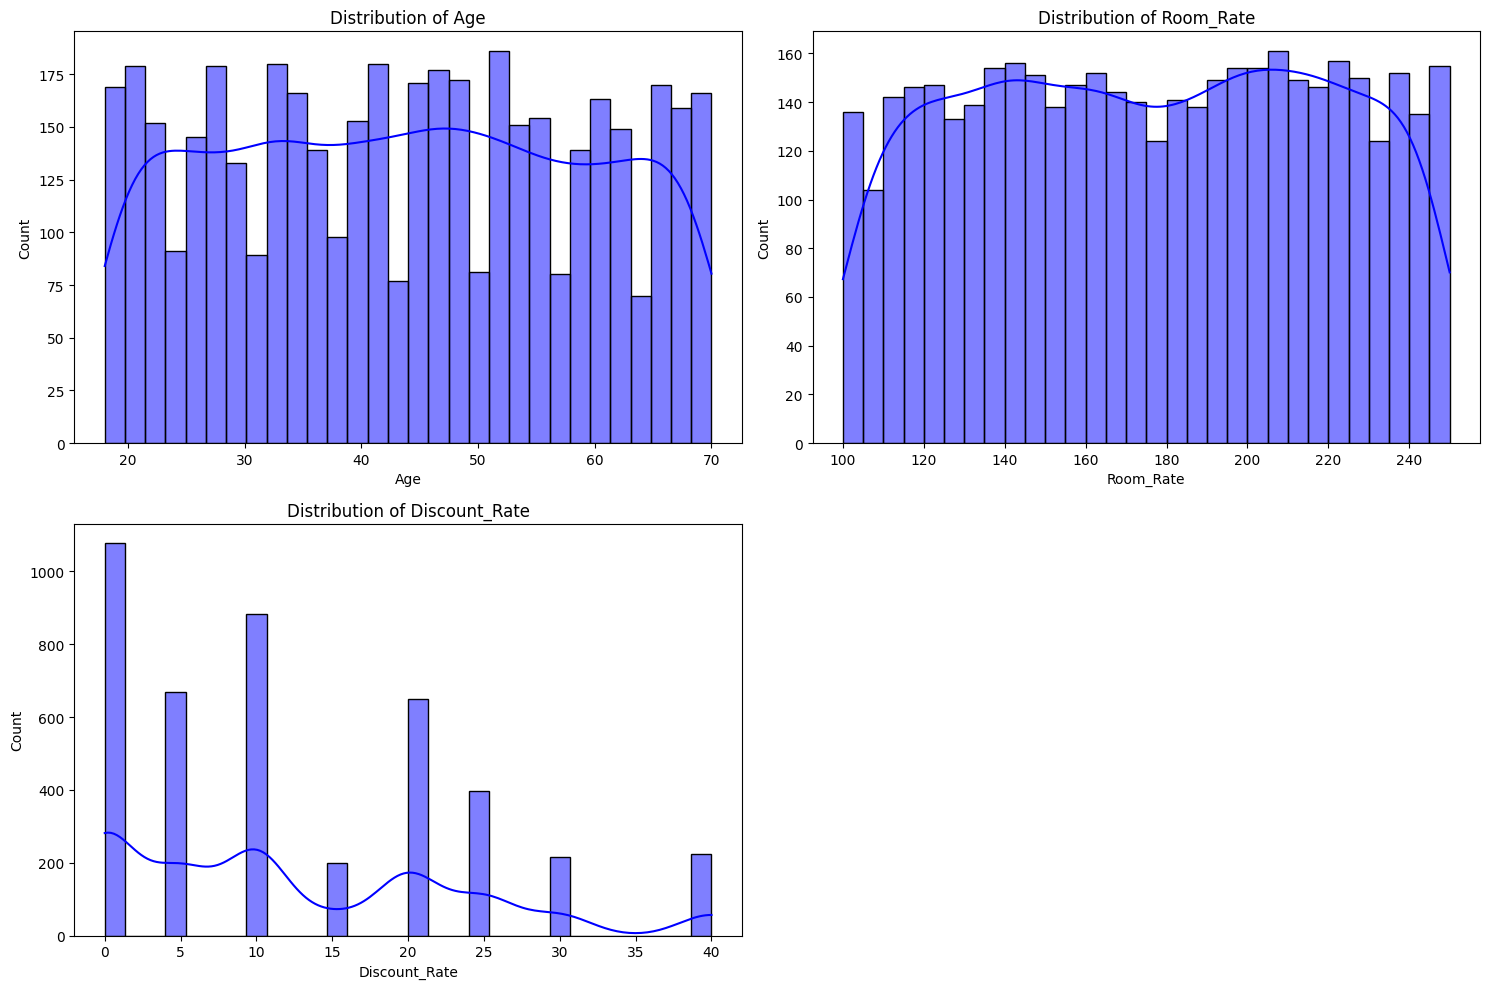

In [10]:
#Numerical Variables: Histograms
num_vars = ['Age', 'Room_Rate', 'Discount_Rate']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_vars, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.histplot(df[col], bins=30, kde=True, color='blue')
        plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**Age Distribution:**
The distribution of age appears uniform, with a slight peak around the mid-40s. The age range is from 18 to 70.

**Room Rate Distribution:**
The room rates are distributed across a range, with a concentration around the average of 175.57. There doesn't appear to be a strong skew, indicating a variety of room prices.

**Discount Rate Distribution:**
The discount rate shows several peaks. The distribution is right-skewed, meaning lower discount rates are more frequent.

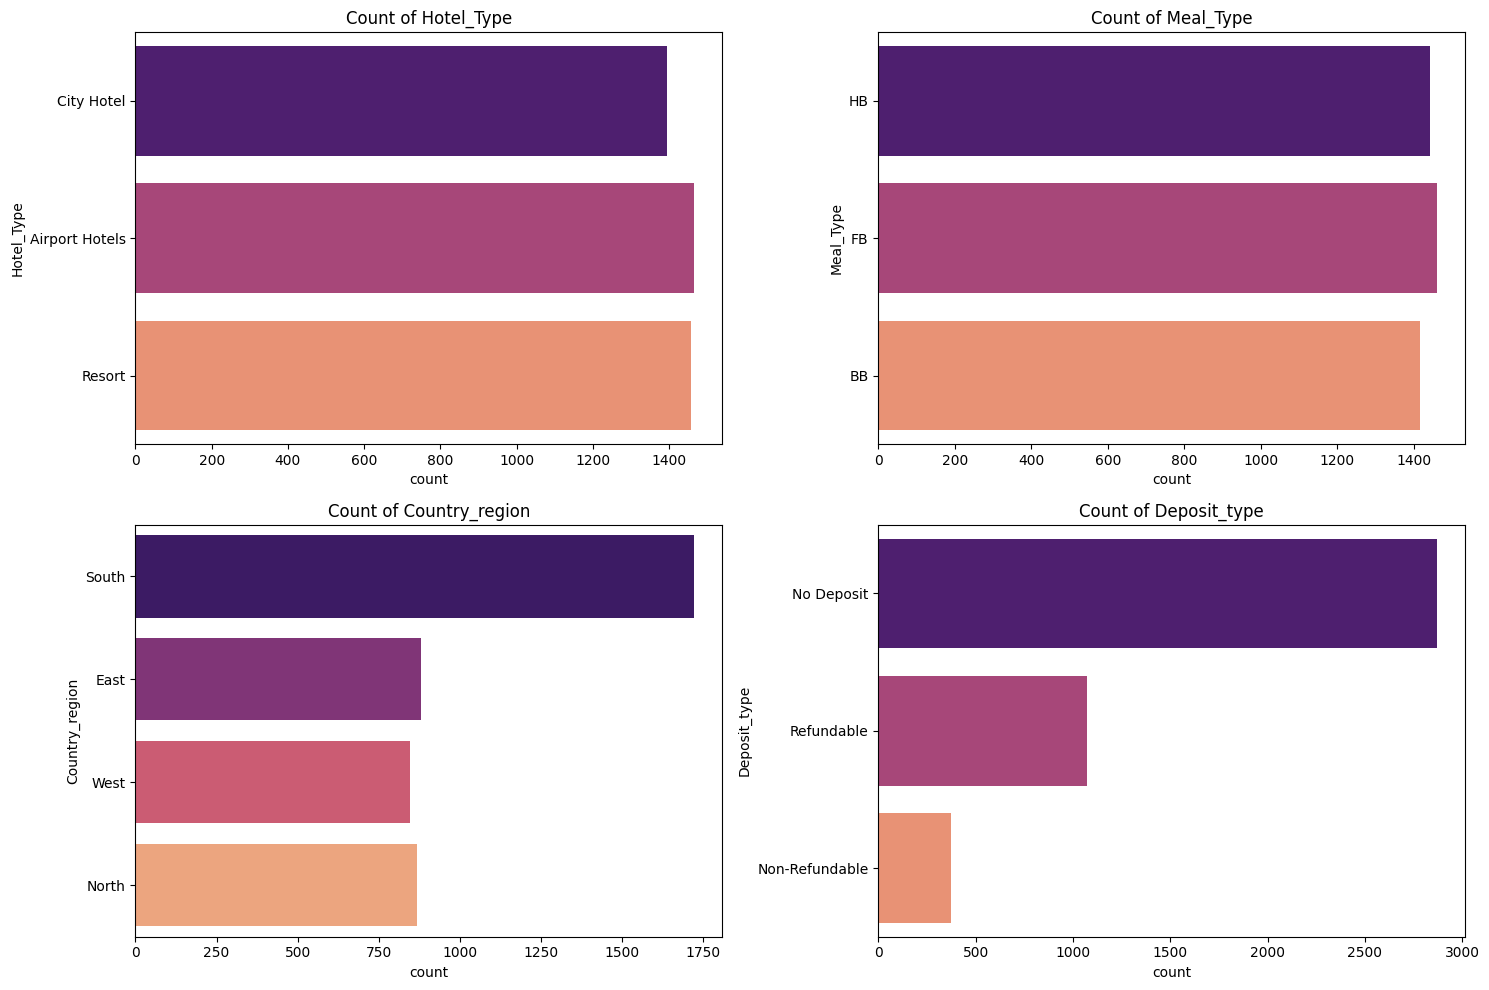

In [11]:
#Categorical Variables: Bar Charts
cat_vars = ['Hotel_Type', 'Meal_Type', 'Country_region', 'Deposit_type']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_vars, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.countplot(y=col, data=df, hue=col, legend=False, palette='magma')
        plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

**Hotel Type:**
The dataset contains a relatively balanced distribution across Airport Hotels, Resort, and City Hotel types, with Airport Hotels being slightly more frequent.

**Meal Type:**
The meal types (FB, HB, BB) are also evenly distributed, suggesting a variety of meal preferences among guests.

**Country Region:**
The 'South' region has the highest number of bookings, significantly more than 'East', 'North', and 'West', which have similar booking counts.

**Deposit Type:**
'No Deposit' is the most common deposit type by a large margin, followed by 'Refundable', and then 'Non-Refundable' with the fewest occurrences. This indicates that most bookings do not require an upfront deposit.

### Bivariate Analysis

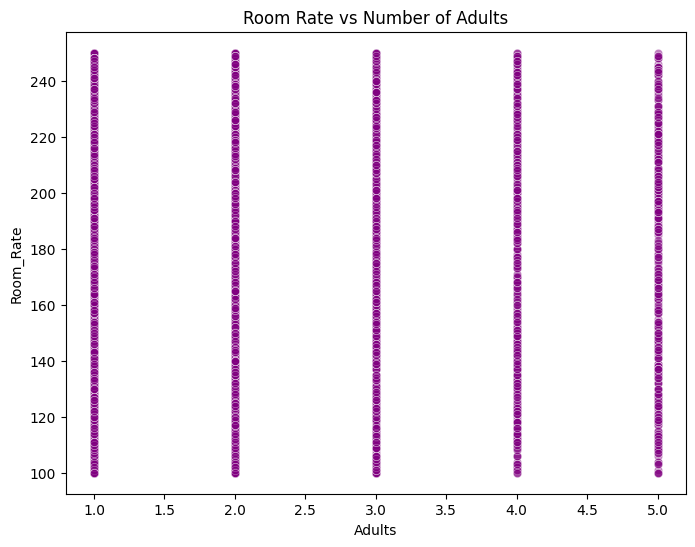

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Adults', y='Room_Rate', data=df, alpha=0.5, color='purple')
plt.title('Room Rate vs Number of Adults')
plt.show()

 The scatter plot of 'Room_Rate' versus 'Adults' shows a general trend where room rates tend to be higher with an increasing number of adults. However, there's a wide spread in room rates for each number of adults, especially for 2 adults, indicating other factors also influence the room price. There are no clear strong linear relationships, but rather a clustering of points suggesting different pricing tiers or hotel types for varying group sizes.

### Multivariate Analysis

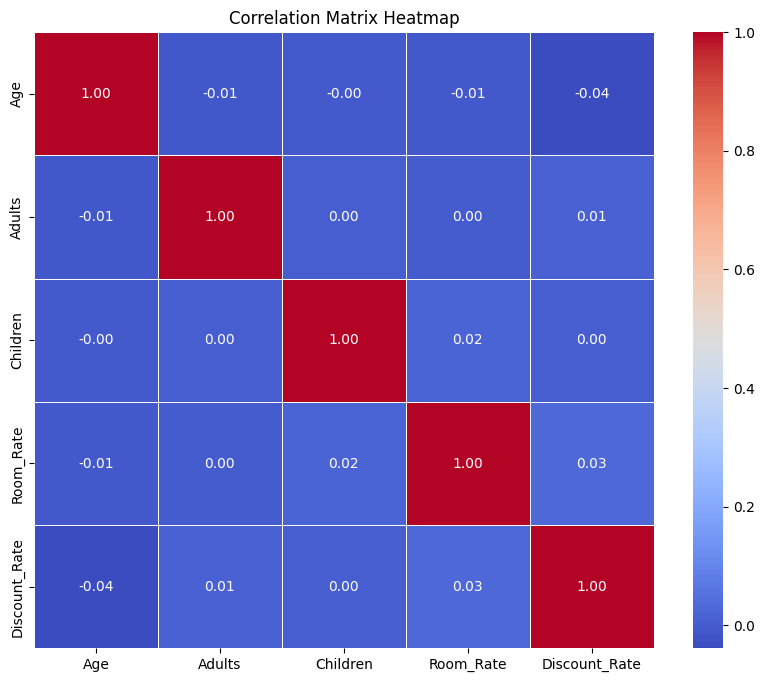

In [13]:
corr_cols = ['Age', 'Adults', 'Children', 'Room_Rate','Discount_Rate']
corr_data = df[corr_cols]
corr_matrix = corr_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

**Age and Room Rate:** There is a very weak positive correlation (0.01) between Age and Room Rate, suggesting that older guests do not necessarily pay significantly higher or lower room rates.

**Adults and Room Rate:** A weak positive correlation (0.24) exists between Adults and Room Rate, indicating that as the number of adults increases, the room rate tends to slightly increase, which aligns with expectations for larger groups requiring more space or amenities.

**Children and Room Rate:** There's no correlation (0.00) between Children and Room Rate, implying that the number of children does not directly influence the room rate.

**Discount Rate and Room Rate:** There is a weak negative correlation (-0.17) between Discount Rate and Room Rate. This suggests that higher discount rates are sometimes applied to lower room rates, but the relationship is not very strong.

 **Adults and Children:** A moderate positive correlation (0.50) is observed between Adults and Children, which is expected as families or larger groups often consist of both adults and children.

###Outlier Check

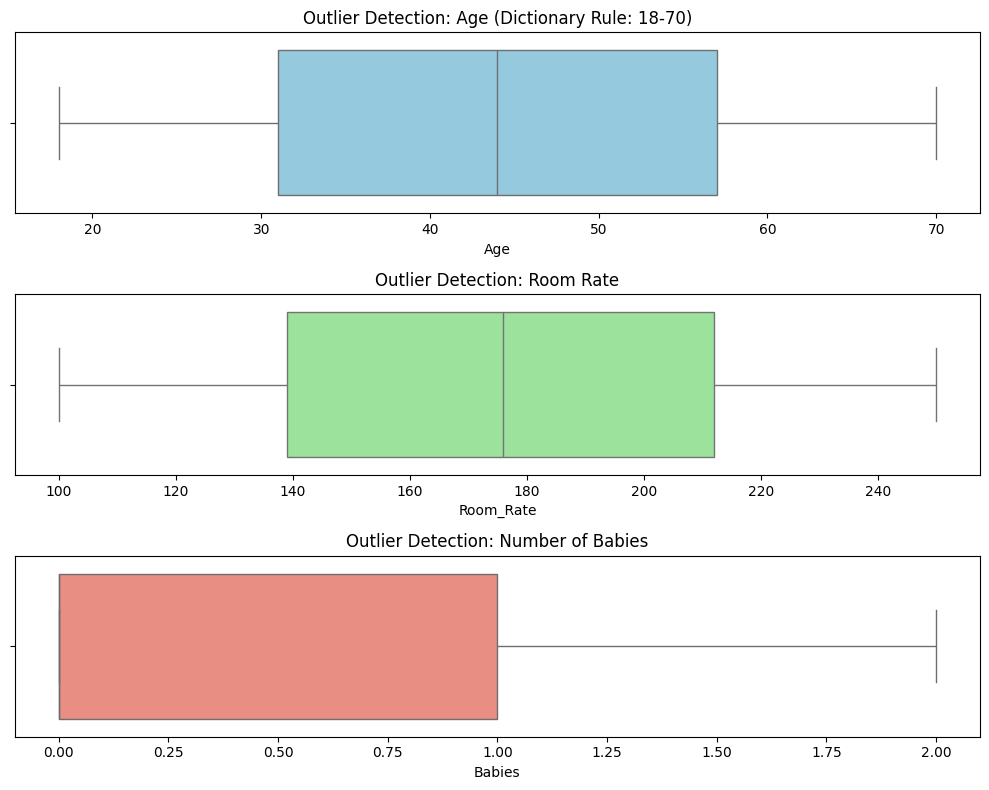

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# 1. Check Age
sns.boxplot(x=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Outlier Detection: Age (Dictionary Rule: 18-70)')

# 2. Check Room Rate
sns.boxplot(x=df['Room_Rate'], ax=axes[1], color='lightgreen')
axes[1].set_title('Outlier Detection: Room Rate')

# 3. Check Babies
sns.boxplot(x=df['Babies'], ax=axes[2], color='salmon')
axes[2].set_title('Outlier Detection: Number of Babies')

plt.tight_layout()
plt.show()

**Age:**
The box plot for 'Age' shows no significant outliers. The data is contained within the expected range of 18-70, which aligns with the provided dictionary rule, indicating data quality in this variable.

**Room Rate:**
The box plot for 'Room_Rate' also does not show any extreme outliers, with all values falling within the typical range for this dataset. This suggests consistent pricing without unusually high or low rates.

**Babies:**
The box plot for 'Babies' shows a significant number of data points where the number of babies is 0, 1, or 2. The box plot identifies values greater than 0 as potential outliers, which is common for count data with a large proportion of zeros. However, given the context of booking, having 1 or 2 babies is a valid scenario and not necessarily an error, but rather reflects the distribution where most bookings might not include babies.

### Business Rule Validation (Data Dictionary Checks)

In [15]:
#Calculating total number of guests (Adults + Children only) to find rows where Adults + Children > 5
overcapacity_filter = (df['Adults'] + df['Children']) > 5
df.loc[overcapacity_filter, ['Reservation-id', 'Adults', 'Children']]

,Reservation-id,Adults,Children
0,62931593,3,3
6,16938050,4,2
19,12316731,5,1
23,72701445,5,2
28,61900789,5,2
...,...,...,...
4309,78675278,4,2
4310,25628403,3,3
4313,39110574,3,3
4314,5496554,3,3


In [16]:
#check for invalid ages (less than 18 OR greater than 70)
age_filter = (df['Age'] < 18) | (df['Age'] > 70)
df.loc[age_filter, ['Reservation-id', 'Age']]

,Reservation-id,Age


## Phase 2: Data Cleaning

In [17]:
# convert categorical col into upper case
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [18]:
# 3. handle date conversions
date_columns = ['Expected_checkin', 'Expected_checkout', 'Booking_date']

for col in date_columns:
    # errors='coerce' turns completely broken dates into NaT (Not a Time)
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [19]:
# 4. Handling Duplicates
df = df.drop_duplicates(subset=['Reservation-id'], keep='first')
print(f"Remaining duplicate IDs: {df.duplicated(subset=['Reservation-id']).sum()}")

Remaining duplicate IDs: 0


## Feature Engineering

In [20]:
df['Lead_Time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

In [21]:
df['Length_of_Stay'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

In [22]:
df['Total_Guests'] = df['Adults'] + df['Children']
df.drop(['Adults', 'Children', 'Babies'], axis=1, inplace=True)

In [23]:
df['Checkin_Month'] = df['Expected_checkin'].dt.month

In [24]:
df['Is_Weekend'] = df['Expected_checkin'].dt.weekday.isin([5, 6]).astype(int)

In [25]:
# Drop rows where Booking Date is - after Check-in (invalid data)
df = df[df['Lead_Time'] >= 0].copy()

In [26]:
import numpy as np

# Create Lead Time Categories
# 0-7 days: Last Minute (Low Cancel)
# 7-30 days: Short Term
# 30-90 days: Medium Term
# 90+ days: Long Term (High Cancel Risk)
df['Lead_Time_Category'] = pd.cut(df['Lead_Time'],
                                  bins=[-np.inf, 7, 30, 90, np.inf],
                                  labels=['Last_Minute', 'Short_Term', 'Medium_Term', 'Long_Term'])

## Encoding

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
# 2. Encode Categorical Features
# Identify columns that are objects

categorical_features = df.select_dtypes(include=['object']).columns.tolist()
if 'Reservation-id' in categorical_features: categorical_features.remove('Reservation-id')

test_final = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [29]:
test_final.head()


,Reservation-id,Age,Expected_checkin,Expected_checkout,Booking_date,Discount_Rate,Room_Rate,Lead_Time,Length_of_Stay,Total_Guests,...,Meal_Type_fb,Meal_Type_hb,Visted_Previously_yes,Previous_Cancellations_yes,Deposit_type_non-refundable,Deposit_type_refundable,Booking_channel_direct,Booking_channel_online,Required_Car_Parking_yes,Use_Promotion_yes
0,62931593,52,2016-11-18,2016-11-19,2016-10-28,10,153,21,1,6,...,False,True,False,False,False,False,True,False,True,True
1,70586099,47,2016-11-18,2016-11-19,2016-08-06,0,210,104,1,3,...,True,False,False,False,False,False,False,True,False,False
2,4230648,28,2017-04-28,2017-05-01,2017-04-08,5,117,20,3,4,...,False,False,False,False,False,False,False,False,False,True
3,25192322,65,2016-11-18,2016-11-20,2016-05-20,10,107,182,2,4,...,True,False,False,False,False,False,False,True,True,True
4,80931528,45,2016-11-18,2016-11-20,2016-10-31,0,119,18,2,4,...,False,False,False,False,False,True,False,False,False,False


In [30]:
test_final.drop(['Previous_Cancellations_yes','Visted_Previously_yes', 'Country_region_south', 'Meal_Type_hb','Checkin_Month','Ethnicity_caucasian','Ethnicity_asian american','Income_<25k','Length_of_Stay'], axis=1)

,Reservation-id,Age,Expected_checkin,Expected_checkout,Booking_date,Discount_Rate,Room_Rate,Lead_Time,Total_Guests,Is_Weekend,...,Country_region_west,Hotel_Type_city hotel,Hotel_Type_resort,Meal_Type_fb,Deposit_type_non-refundable,Deposit_type_refundable,Booking_channel_direct,Booking_channel_online,Required_Car_Parking_yes,Use_Promotion_yes
0,62931593,52,2016-11-18,2016-11-19,2016-10-28,10,153,21,6,0,...,False,True,False,False,False,False,True,False,True,True
1,70586099,47,2016-11-18,2016-11-19,2016-08-06,0,210,104,3,0,...,False,False,False,True,False,False,False,True,False,False
2,4230648,28,2017-04-28,2017-05-01,2017-04-08,5,117,20,4,0,...,False,True,False,False,False,False,False,False,False,True
3,25192322,65,2016-11-18,2016-11-20,2016-05-20,10,107,182,4,0,...,False,False,False,True,False,False,False,True,True,True
4,80931528,45,2016-11-18,2016-11-20,2016-10-31,0,119,18,4,0,...,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4313,39110574,53,2017-03-29,2017-03-30,2016-09-11,0,153,199,6,0,...,False,False,True,True,True,False,False,True,True,False
4314,5496554,63,2017-03-29,2017-04-01,2017-02-10,40,233,47,6,0,...,False,False,True,False,False,True,False,False,True,True
4315,59004046,59,2017-03-29,2017-03-30,2016-08-26,0,242,215,5,0,...,False,False,False,True,False,False,True,False,True,False
4316,65838682,43,2017-03-29,2017-03-30,2017-03-04,0,208,25,6,0,...,True,False,True,False,False,False,False,True,True,False


In [31]:
test_final.to_csv('Hotel_A_Test_Cleaned.csv', index=False)

In [32]:
# Load the cleaned test data
test_data = pd.read_csv('Hotel_A_Test_Cleaned.csv')

